# INSTALLS & GLOBAL PARAMETERS

In [2]:
!pip install optuna xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict, Any, Union, Tuple, List

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import warnings
import time
import optuna
import optuna.logging

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from optuna import Trial

URL_DATA = 'data/antenna_dataset.csv'

In [4]:
columns_description = [
    {
        "name": "S11",
        "description": "Reflection coefficient (input return loss) indicating how much power is reflected",
        "unit": "dB",
        "notes": "More negative = better matching (e.g. < -10 dB acceptable, < -20 dB excellent)"
    },
    {
        "name": "VSWR",
        "description": "Voltage Standing Wave Ratio derived from reflection coefficient",
        "unit": "ratio",
        "notes": "1.0 = perfect match, < 2 acceptable, > 2 indicates mismatch"
    },
    {
        "name": "Gain",
        "description": "Antenna realized gain (includes efficiency and directivity)",
        "unit": "dBi",
        "notes": "Higher = stronger radiation in a direction"
    },
    {
        "name": "Efficiency",
        "description": "Radiation efficiency (fraction of input power radiated)",
        "unit": "%",
        "notes": ">70% generally good"
    },
    {
        "name": "Bandwidth",
        "description": "Frequency range where antenna meets matching criteria",
        "unit": "MHz",
        "notes": "Typically defined for S11 < -10 dB"
    },
    {
        "name": "Z_Real",
        "description": "Real part of input impedance (resistive component)",
        "unit": r"$\Omega$",
        "notes": "Target ~50Ω for impedance matching"
    },
    {
        "name": "Z_Imag",
        "description": "Imaginary part of input impedance (reactive component)",
        "unit": r"$\Omega$",
        "notes": "0Ω ideal; +ve inductive, -ve capacitive"
    },
    {
        "name": "Status",
        "description": "Binary classification target indicating antenna condition",
        "unit": "-",
        "notes": "0 = Healthy, 1 = Faulty"
    },
    {
        "name": "Fault_Type",
        "description": "Multiclass classification target specifying fault category",
        "unit": "-",
        "notes": "0=Healthy, 1=Broken, 2=Length Var, 3=Bad Conn, 4=Bending, 5=Humidity"
    }
]

# Preprocessing

In [5]:
df = pd.read_csv(URL_DATA)
print(df.head())
print(df.info())

   S11 (dB)      VSWR  Gain (dBi)   Eff (%)  BW (MHz)  Z_Real (Ohms)  \
0  0.054466 -0.631356    0.422205  0.361451  0.904843      -0.038140   
1  0.115230 -0.329512    0.397559  0.109627  0.698747      -0.304900   
2  1.071530  0.836072   -1.270175 -1.140808 -1.238553      -1.475135   
3  0.961577  2.693575   -2.465521 -1.171201 -1.114896      -1.195323   
4  0.897920  0.654965   -0.921019 -0.915035 -1.320991      -1.194915   

   Z_Imag (Ohms)  Status  Fault_Type  
0       0.519633       1           1  
1      -0.689372       1           4  
2       2.461611       1           2  
3       1.660919       1           2  
4       2.287132       1           2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   S11 (dB)       1500 non-null   float64
 1   VSWR           1500 non-null   float64
 2   Gain (dBi)     1500 non-null   float64
 3   Ef

In [6]:
def get_info_dataset(df: pd.DataFrame, columns_description: List[Dict[str, str]]) -> pd.DataFrame:

    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', None)

    null_count, not_null_count = df.isnull().sum(), df.count()
    unique_count = df.nunique().values
    unique_values = [df[col].unique()[:5] for col in df.columns]
    len_df = len(df)

    return pd.DataFrame({
        'Column': df.columns,
        'About column': [desc["description"] for desc in columns_description],
        'Unit': [desc["unit"] for desc in columns_description],
        'Notes': [desc["notes"] for desc in columns_description],
        'Dtype': [df[col].dtype for col in df.columns],
        'Not Null Count': not_null_count.values,
        'Null Count': null_count.values,
        '% Null of Total': ((null_count / len_df) * 100).round(2).values,
        'Unique_count': unique_count,
        'Sample_Values': unique_values
    })

In [7]:
def df_rename_columns(df: pd.DataFrame) -> pd.DataFrame:

    rename_map = {
        "Z_Real (Ohms)": "Z_Real",
        "Z_Imag (Ohms)": "Z_Imag",
        "S11 (dB)": "S11",
        "Gain (dBi)": "Gain",
        "Eff (%)": "Eff",
        "BW (MHz)": "BW"
    }

    available_cols = set(df.columns)
    actual_renames = {k: v for k, v in rename_map.items() if k in available_cols}

    df = df.rename(columns=actual_renames)

    print(f"Renamed {len(actual_renames)} columns")

    return df


In [8]:
display(get_info_dataset(df, columns_description))
print(df.describe())

,Column,About column,Unit,Notes,Dtype,Not Null Count,Null Count,% Null of Total,Unique_count,Sample_Values
0,S11 (dB),Reflection coefficient (input return loss) indicating how much power is reflected,dB,"More negative = better matching (e.g. < -10 dB acceptable, < -20 dB excellent)",float64,1500,0,0.0,1014,"[0.0544662136291067, 0.1152296401424273, 1.0715302336020676, 0.9615773665779638, 0.8979204435640089]"
1,VSWR,Voltage Standing Wave Ratio derived from reflection coefficient,ratio,"1.0 = perfect match, < 2 acceptable, > 2 indicates mismatch",float64,1500,0,0.0,526,"[-0.6313561170932478, -0.3295118150951225, 0.8360715664668685, 2.6935749633784085, 0.6549649852679936]"
2,Gain (dBi),Antenna realized gain (includes efficiency and directivity),dBi,Higher = stronger radiation in a direction,float64,1500,0,0.0,699,"[0.4222049993378274, 0.3975586883662662, -1.2701750207093745, -2.4655211028300923, -0.9210189486122576]"
3,Eff (%),Radiation efficiency (fraction of input power radiated),%,>70% generally good,float64,1500,0,0.0,662,"[0.3614510687437259, 0.1096272865256167, -1.1408080458677536, -1.1712005713078704, -0.915034999741173]"
4,BW (MHz),Frequency range where antenna meets matching criteria,MHz,Typically defined for S11 < -10 dB,float64,1500,0,0.0,91,"[0.9048428887076936, 0.6987471141295929, -1.2385531669045546, -1.1148957021576942, -1.320991476735795]"
5,Z_Real (Ohms),Real part of input impedance (resistive component),$\Omega$,Target ~50Ω for impedance matching,float64,1500,0,0.0,1338,"[-0.0381401152315947, -0.3048998457458203, -1.4751348103411006, -1.195322615948503, -1.194914726452304]"
6,Z_Imag (Ohms),Imaginary part of input impedance (reactive component),$\Omega$,"0Ω ideal; +ve inductive, -ve capacitive",float64,1500,0,0.0,1326,"[0.519633386109163, -0.6893721923655272, 2.4616110451088717, 1.660918718013607, 2.287131821592589]"
7,Status,Binary classification target indicating antenna condition,-,"0 = Healthy, 1 = Faulty",int64,1500,0,0.0,2,"[1, 0]"
8,Fault_Type,Multiclass classification target specifying fault category,-,"0=Healthy, 1=Broken, 2=Length Var, 3=Bad Conn, 4=Bending, 5=Humidity",int64,1500,0,0.0,6,"[1, 4, 2, 0, 5]"


           S11 (dB)          VSWR    Gain (dBi)       Eff (%)      BW (MHz)  \
count  1.500000e+03  1.500000e+03  1.500000e+03  1.500000e+03  1.500000e+03   
mean  -3.434290e-17  4.618528e-17 -5.447494e-17 -2.131628e-16 -7.105427e-17   
std    1.000334e+00  1.000334e+00  1.000334e+00  1.000334e+00  1.000334e+00   
min   -2.947536e+00 -1.021432e+00 -2.506598e+00 -1.761684e+00 -1.898060e+00   
25%   -2.826261e-01 -6.731499e-01 -6.632596e-01 -7.978067e-01 -8.675808e-01   
50%    1.492282e-01 -4.177432e-01  2.147652e-01 -4.233534e-02  1.422885e-01   
75%    7.854358e-01  5.202960e-01  6.645604e-01  5.872241e-01  6.987471e-01   
max    1.236460e+00  3.120801e+00  1.597012e+00  2.054749e+00  1.811664e+00   

       Z_Real (Ohms)  Z_Imag (Ohms)       Status   Fault_Type  
count   1.500000e+03   1.500000e+03  1500.000000  1500.000000  
mean    2.202682e-16   2.131628e-17     0.833333     2.500000  
std     1.000334e+00   1.000334e+00     0.372802     1.708395  
min    -1.603620e+00  -1.243483e

## Data Visualization

In [9]:
features = [col for col in df.columns if col not in ['Status', 'Fault_Type']]

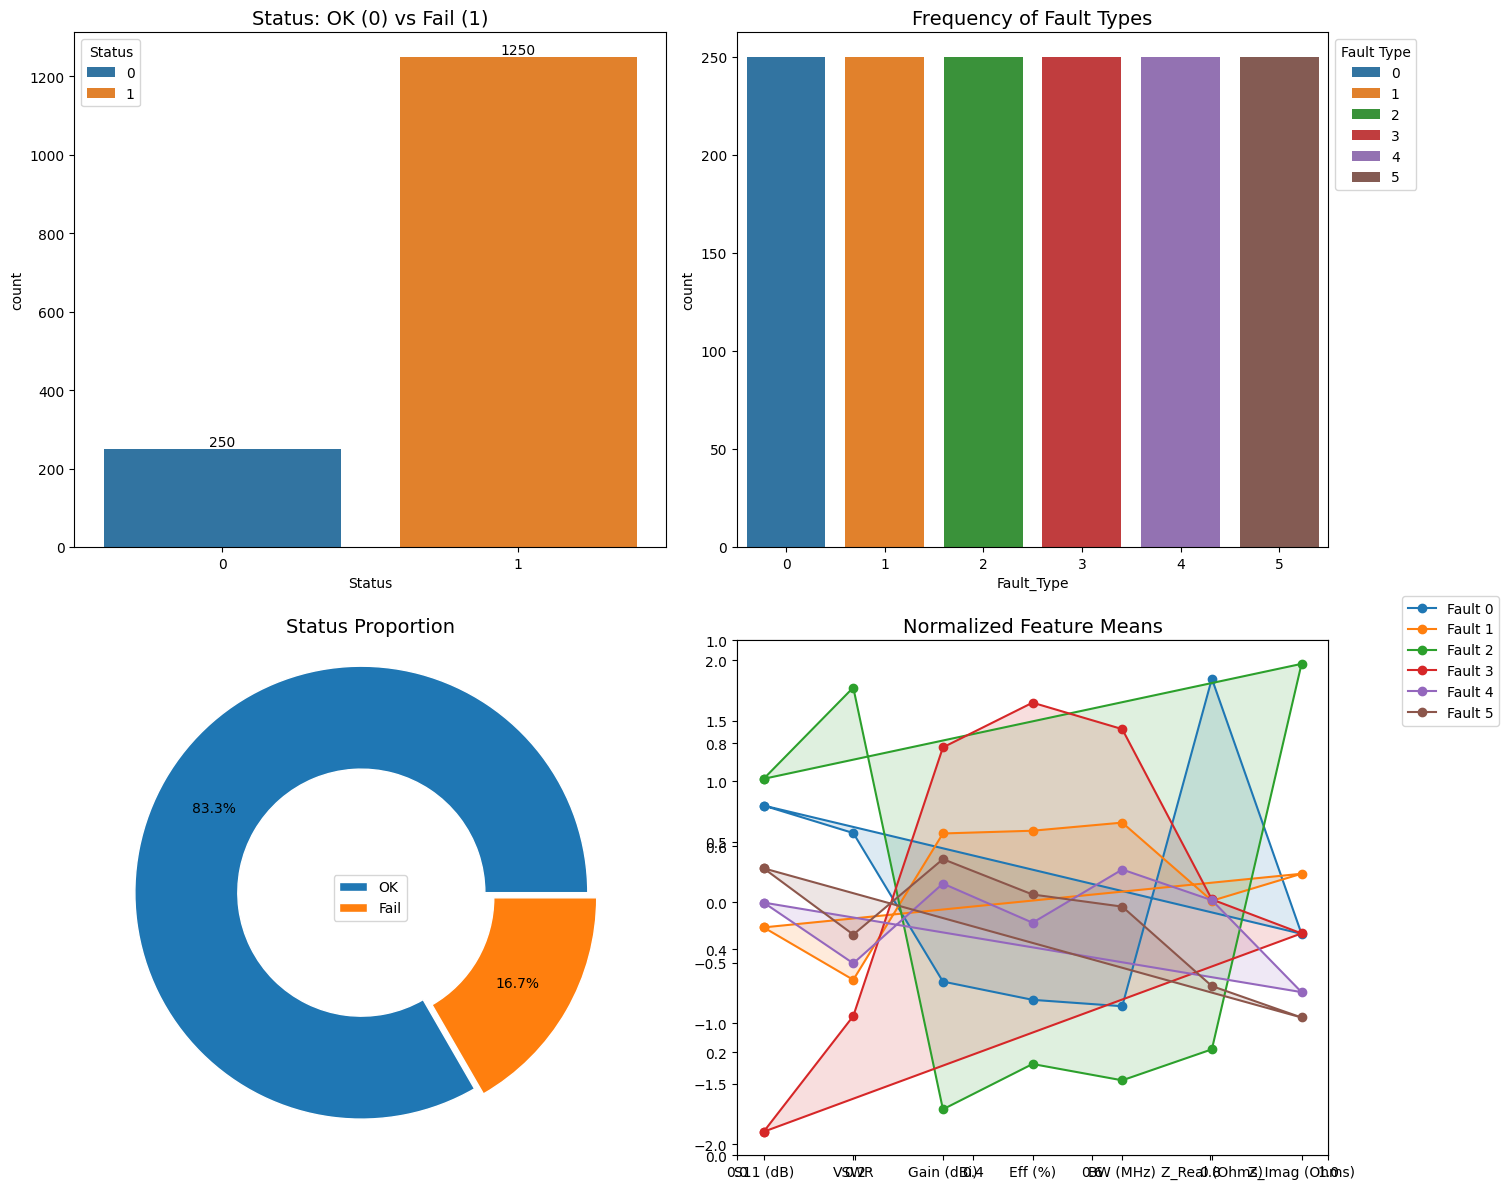

In [11]:
def plot_status_distributions(df: pd.DataFrame, palette: str = "tab10"):

    n_rows, n_cols = 2, 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
    axes = axes.flatten()

    sns.countplot(data=df, x="Status", hue="Status", ax=axes[0], palette=palette)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.0f")
    axes[0].set_title("Status: OK (0) vs Fail (1)", fontsize=14)

    sns.countplot(data=df, x="Fault_Type", hue="Fault_Type", ax=axes[1], palette=palette)
    axes[1].set_title("Frequency of Fault Types", fontsize=14)
    axes[1].legend(title="Fault Type", bbox_to_anchor=(1, 1))

    status_counts = df["Status"].value_counts()
    axes[2].pie(
        status_counts, autopct="%1.1f%%", explode=[0.05, 0],
        pctdistance=0.75, radius=1.1,
        wedgeprops=dict(width=0.5, edgecolor="w")
    )
    axes[2].set_title("Status Proportion", fontsize=14)
    axes[2].legend(["OK", "Fail"], loc="center")

    features = [col for col in df.columns if col not in ["Status", "Fault_Type"]]
    radar_data = df.groupby("Fault_Type")[features].mean()
    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    ax4 = fig.add_subplot(2, 2, 4)
    for i, (fault_type, row) in enumerate(radar_data.iterrows()):
        values = row.values.tolist()
        values += values[:1]
        ax4.plot(angles, values, "o-", linewidth=1.5, label=f"Fault {i}")
        ax4.fill(angles, values, alpha=0.15)

    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(features, fontsize=10)
    ax4.set_title("Normalized Feature Means", fontsize=14)
    ax4.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

plot_status_distributions(df)


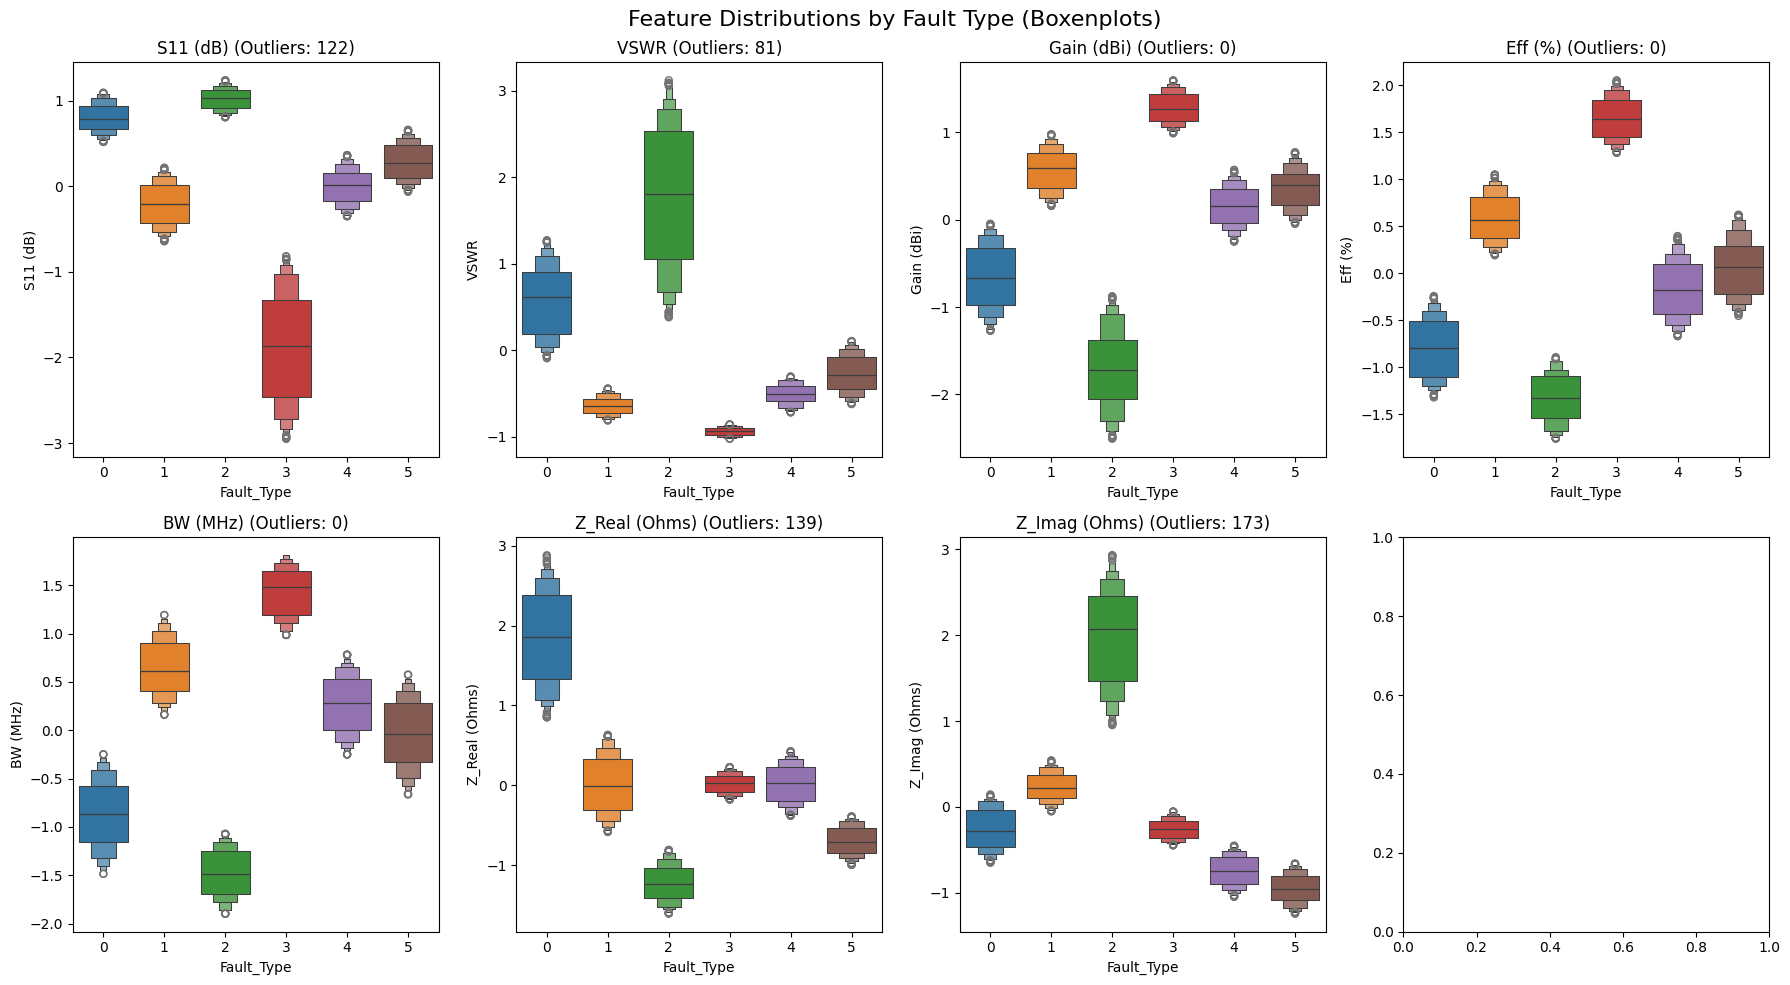

In [12]:
def plot_feature_boxen(df: pd.DataFrame, features: List[str]):

    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    for i, feat in enumerate(features):
        if i >= len(axes): break

        Q1, Q3 = df[feat].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        outliers = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()

        sns.boxenplot(data=df, x="Fault_Type", y=feat, hue="Fault_Type", ax=axes[i], palette="tab10", legend=False)
        axes[i].set_title(f"{feat} (Outliers: {outliers})", fontsize=12)

    plt.suptitle("Feature Distributions by Fault Type (Boxenplots)", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_feature_boxen(df, features)


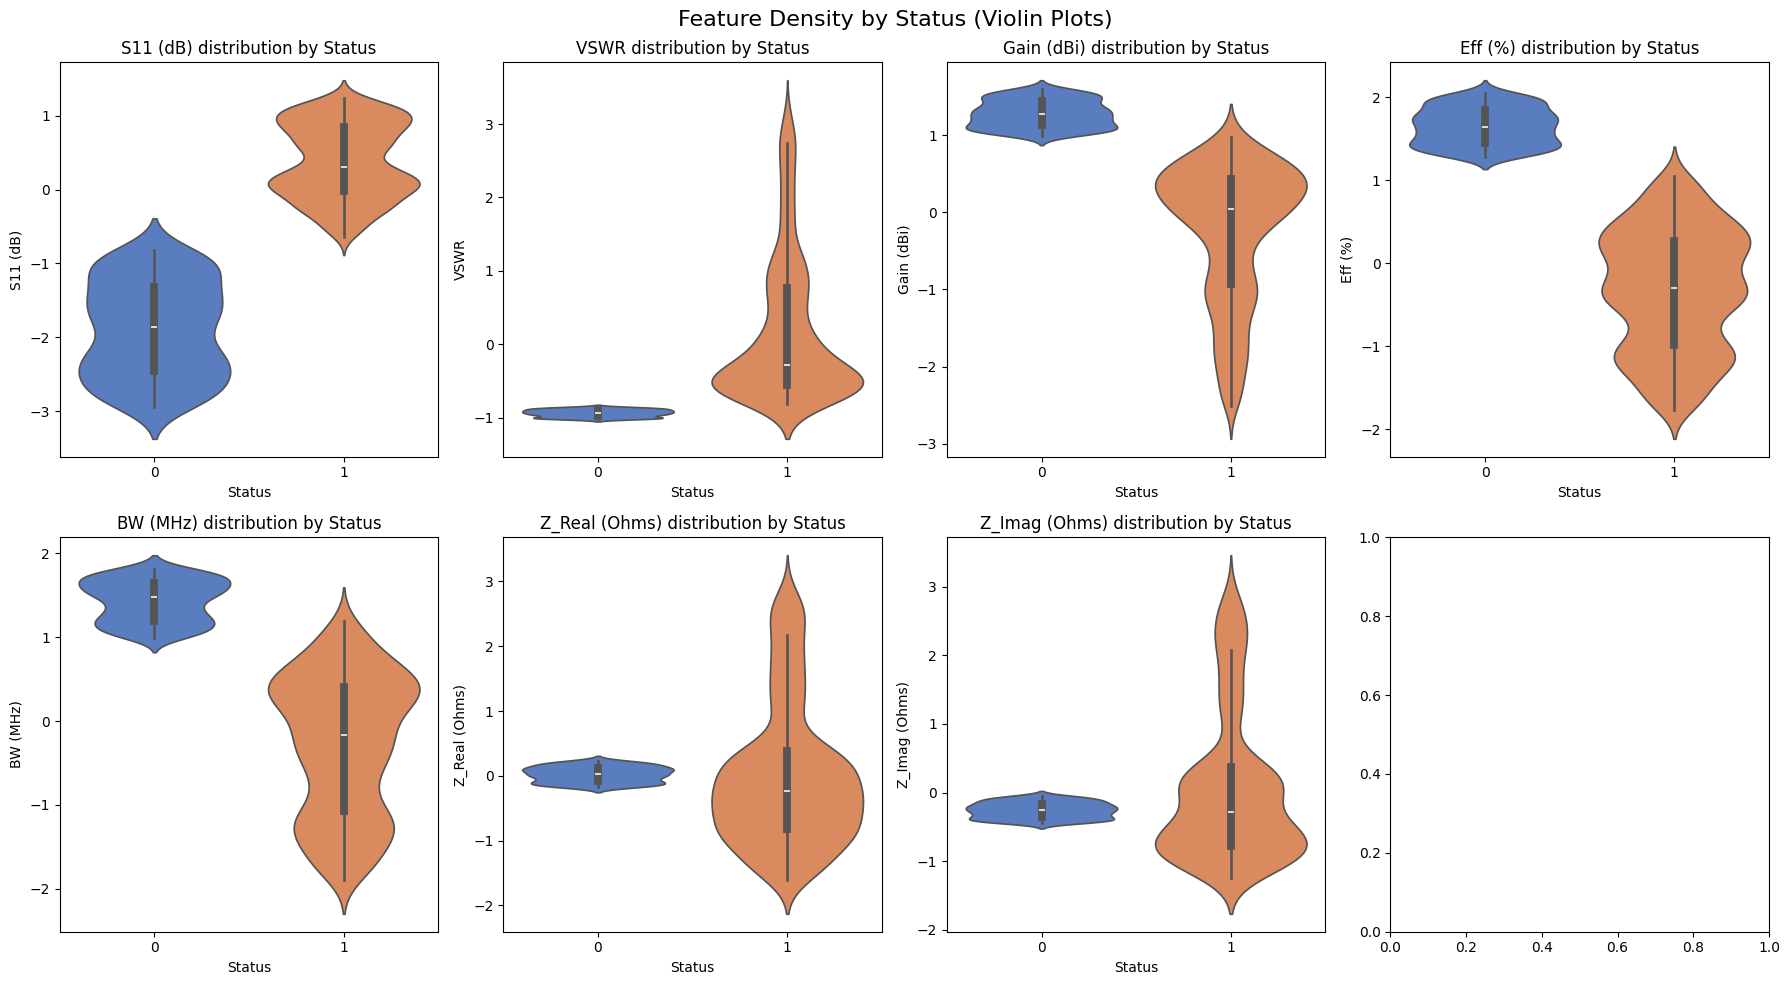

In [13]:
def plot_feature_violins(df: pd.DataFrame, features: List[str]):

    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    for i, feat in enumerate(features):
        if i >= len(axes): break
        sns.violinplot(data=df, x="Status", y=feat, hue="Status", ax=axes[i], palette="muted", legend=False)
        axes[i].set_title(f"{feat} distribution by Status", fontsize=12)

    plt.suptitle("Feature Density by Status (Violin Plots)", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_feature_violins(df, features)


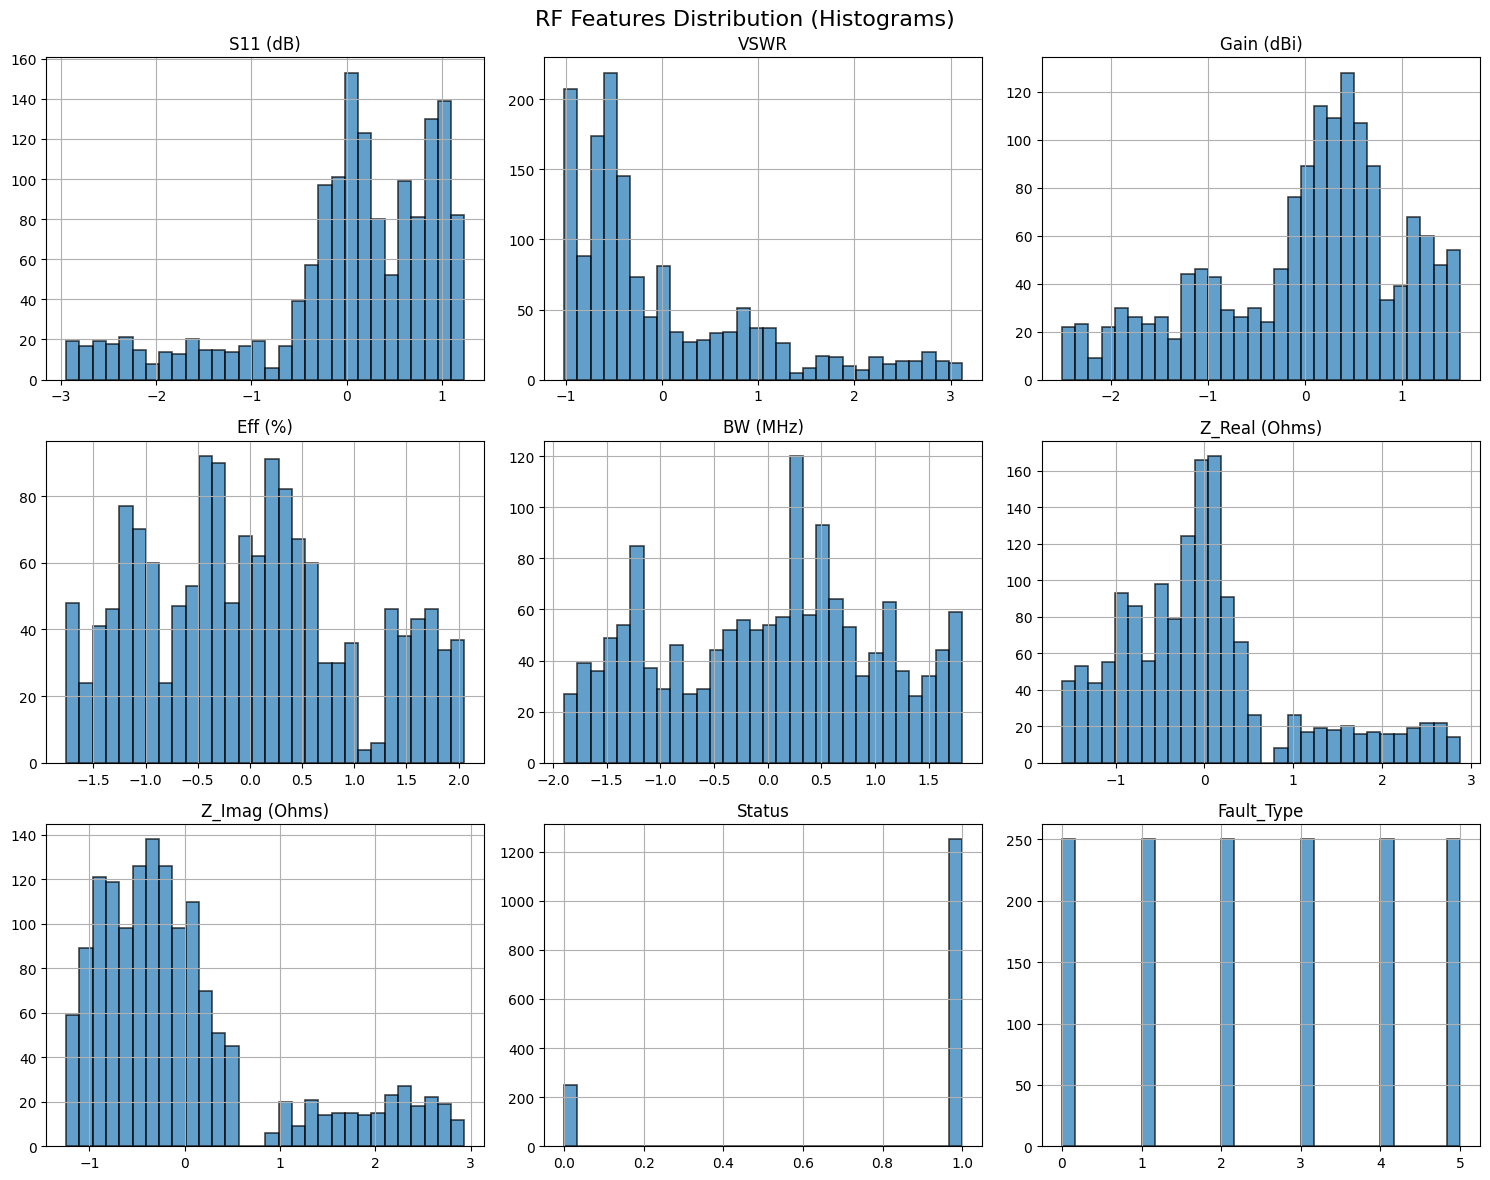

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
df.hist(
    bins=30, ax=axes.flatten()[:len(df.columns)],
    edgecolor="black", linewidth=1.2, alpha=0.7
)
plt.suptitle("RF Features Distribution (Histograms)", fontsize=16)
plt.tight_layout()
plt.show()


<Figure size 2000x2000 with 0 Axes>

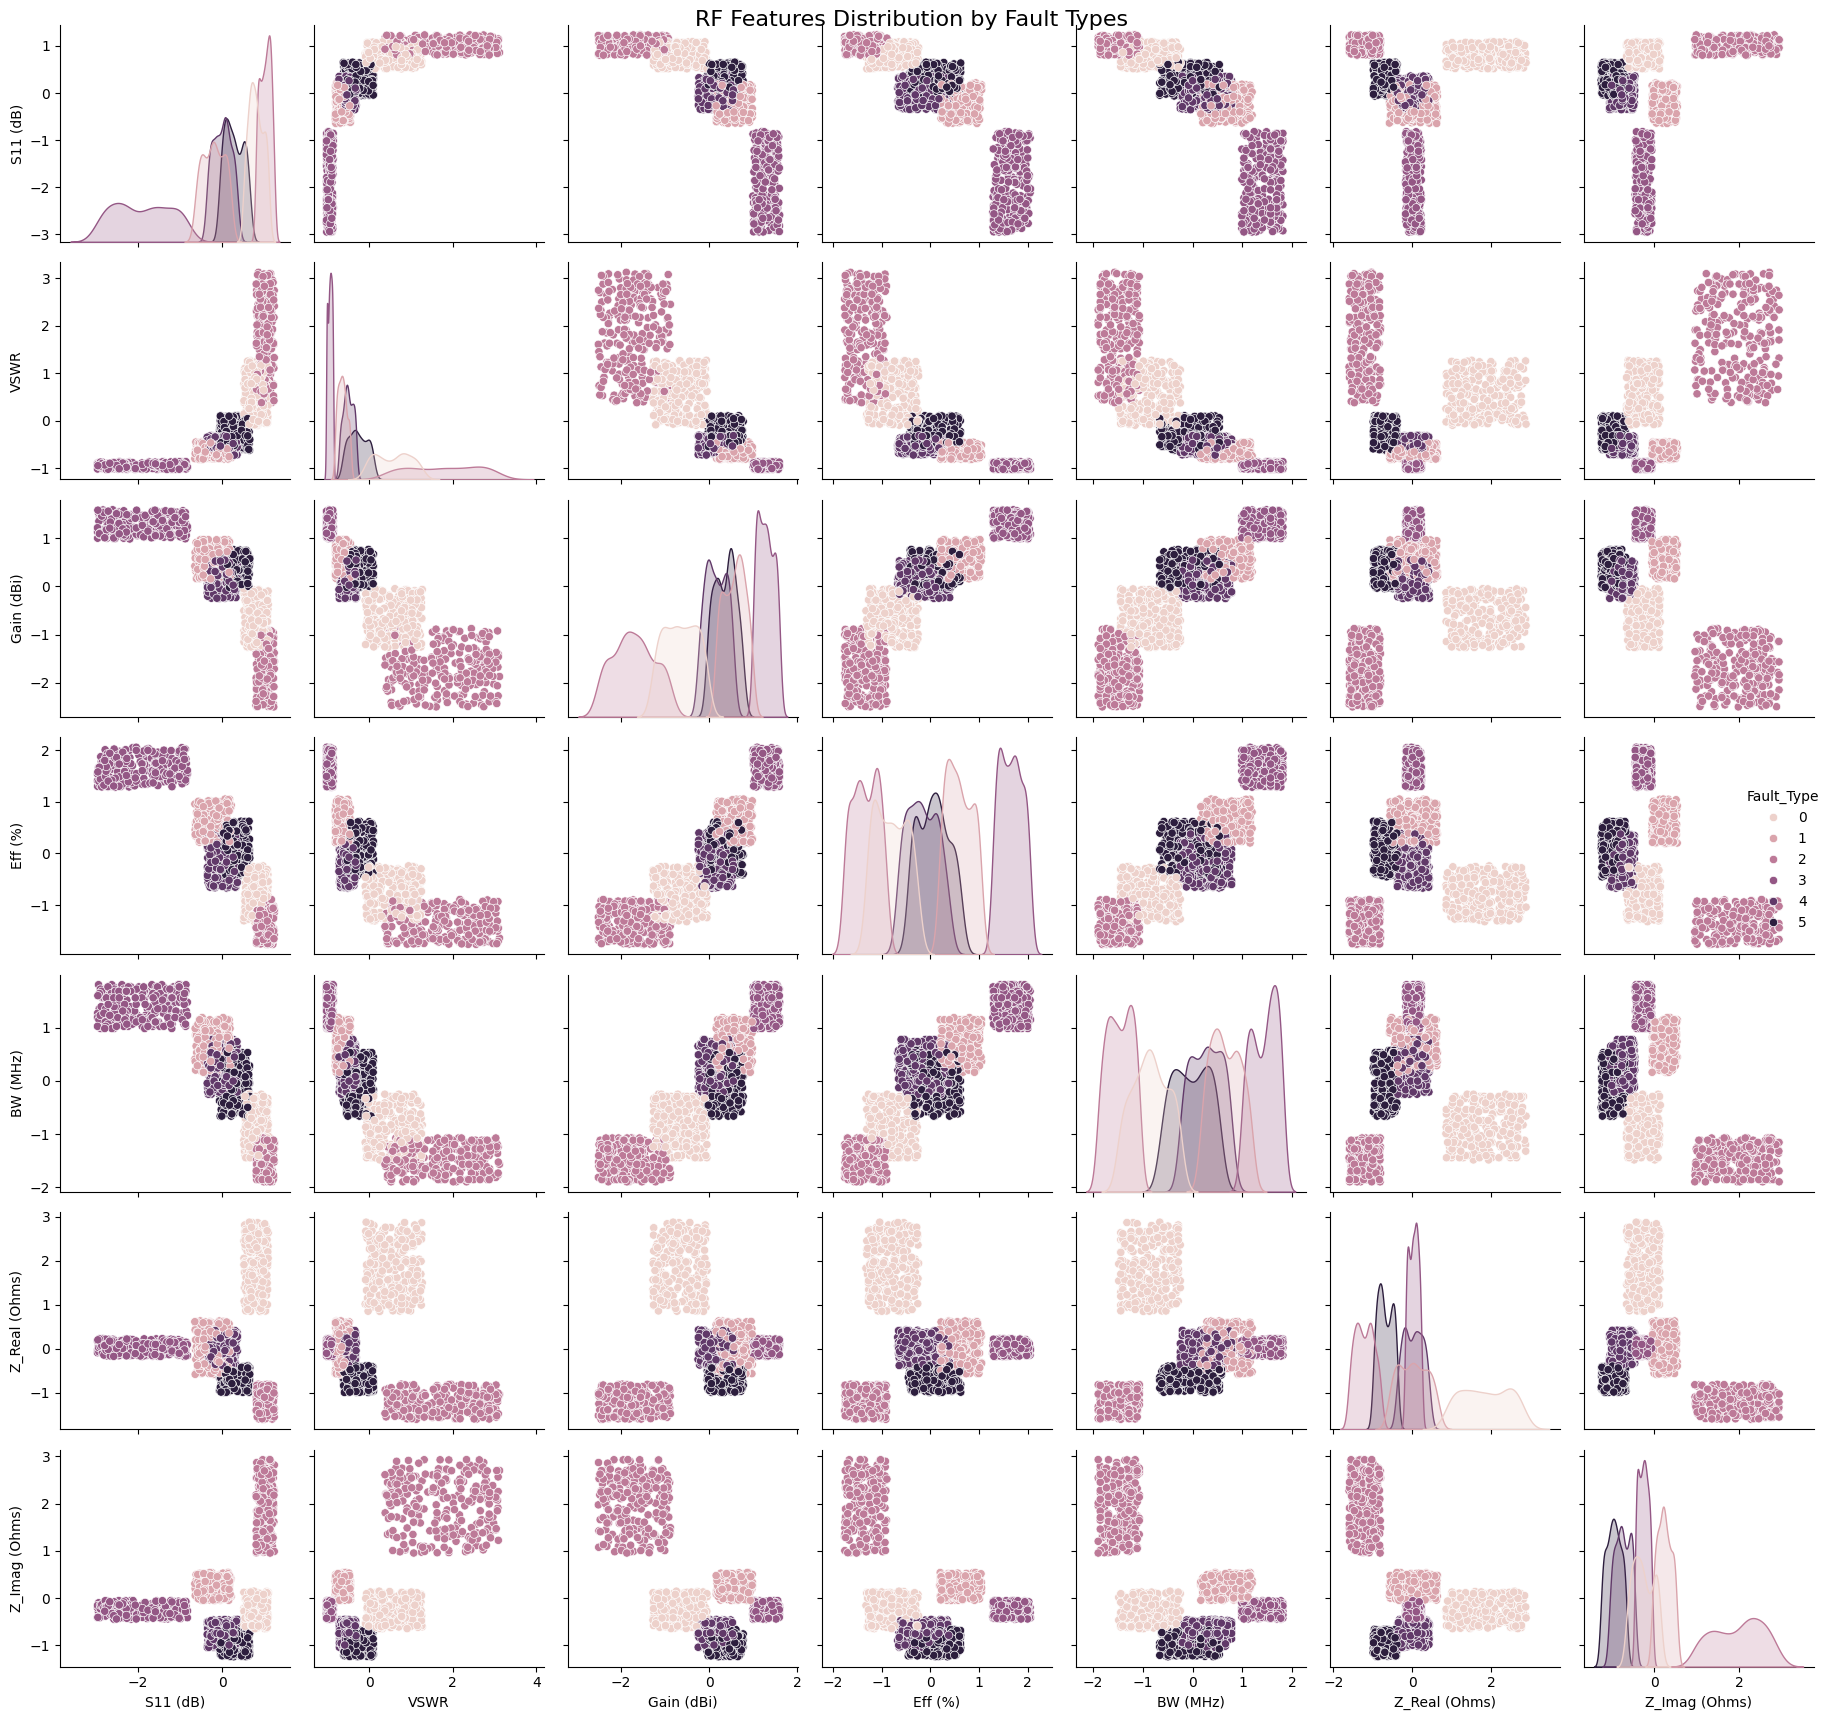

In [15]:
plt.figure(figsize=(20, 20))
sns.pairplot(
    df[features + ['Fault_Type']],
    hue='Fault_Type',
    diag_kind='kde'
)
plt.suptitle('RF Features Distribution by Fault Types', fontsize=16)
plt.tight_layout()
plt.show()

# Exploratory Analysis

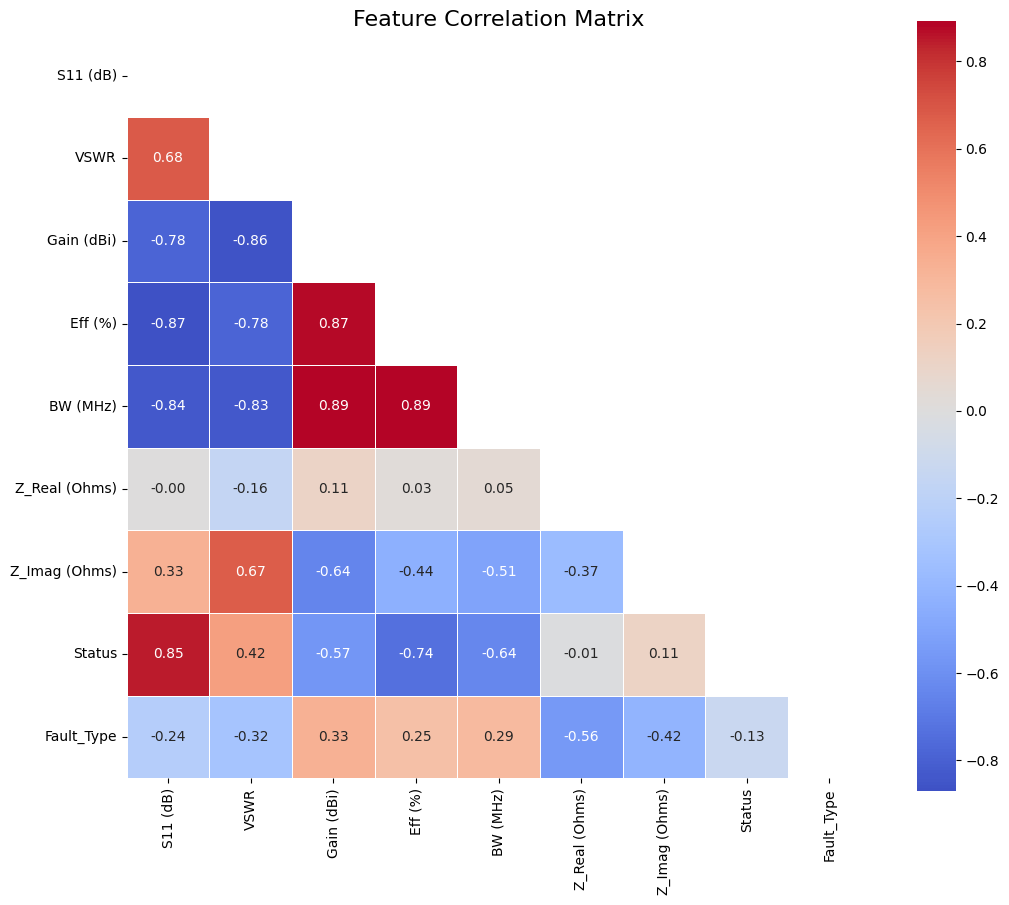

In [16]:
def plot_correlation_matrix(df: pd.DataFrame):

    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(df.corr(), dtype=bool))
    sns.heatmap(
        df.corr(), mask=mask, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, square=True, linewidths=.5
    )
    plt.title("Feature Correlation Matrix", fontsize=16)
    plt.show()

plot_correlation_matrix(df)


## VIF Analysis (Multicollinearity) on base features

In [17]:
def calculate_vif(df: pd.DataFrame, features: List[str]) -> pd.DataFrame:

    X = add_constant(df[features])
    vif_data = pd.DataFrame({"Feature": features})
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
    vif_data = vif_data.sort_values("VIF", ascending=False)

    plt.figure(figsize=(12, 6))
    colors = ["#2ecc71" if x < 5 else "#f1c40f" if x < 10 else "#e74c3c" for x in vif_data["VIF"]]
    plt.barh(vif_data["Feature"], vif_data["VIF"], color=colors)
    plt.axvline(x=5, color="#f1c40f", linestyle="--", alpha=0.7, label="Threshold (Moderate)")
    plt.axvline(x=10, color="#e74c3c", linestyle="--", alpha=0.7, label="Threshold (High)")
    plt.title("VIF Scores (Multicollinearity Analysis)", fontsize=16)
    plt.xlabel("VIF Value")
    plt.legend()
    plt.show()

    high_vif = vif_data[vif_data["VIF"] > 10]
    mid_vif = vif_data[(vif_data["VIF"] >= 5) & (vif_data["VIF"] <= 10)]

    print(f"Summary: {len(vif_data)} features analyzed.")
    print(f"High (>10): {len(high_vif)}")
    print(f"Moderate (5-10): {len(mid_vif)}")
    print(f"Normal (<5): {len(vif_data) - len(high_vif) - len(mid_vif)}")

    return vif_data


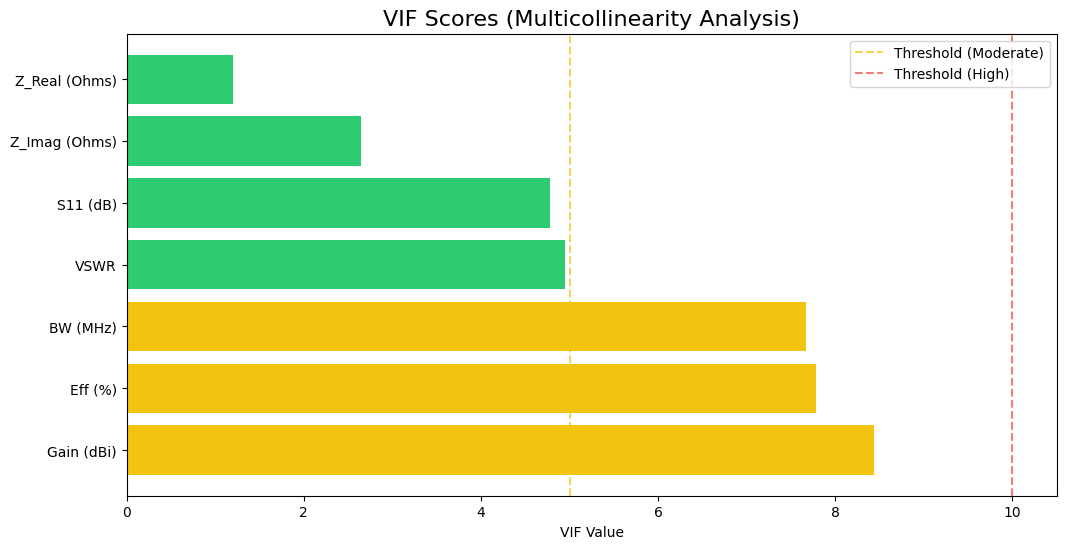

Summary: 7 features analyzed.
High (>10): 0
Moderate (5-10): 3
Normal (<5): 4


In [18]:
curr_features = [col for col in df.columns if col not in ["Status", "Fault_Type"]]
vif_results = calculate_vif(df, curr_features)


## Feature Engineering

In [19]:
def perform_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:

    new_df = df.copy()

    new_df["Z_magnitude"] = np.sqrt(new_df["Z_Real"]**2 + new_df["Z_Imag"]**2)
    new_df["Z_phase_deg"] = np.arctan2(new_df["Z_Imag"], new_df["Z_Real"]) * 180 / np.pi

    new_df["gain_over_eff"] = new_df["Gain"] / (new_df["Eff"] + 1e-8)
    new_df["conductance"] = new_df["Z_Real"] / (new_df["Z_magnitude"]**2 + 1e-12)
    new_df["susceptance"] = new_df["Z_Imag"] / (new_df["Z_magnitude"]**2 + 1e-12)
    new_df["Q_factor"] = new_df["Gain"] / (new_df["BW"] + 1e-6)
    new_df["resonance_quality"] = 1 / (np.abs(new_df["Z_phase_deg"]) + 1e-6)

    return new_df


## VIF on new features

Renamed 6 columns


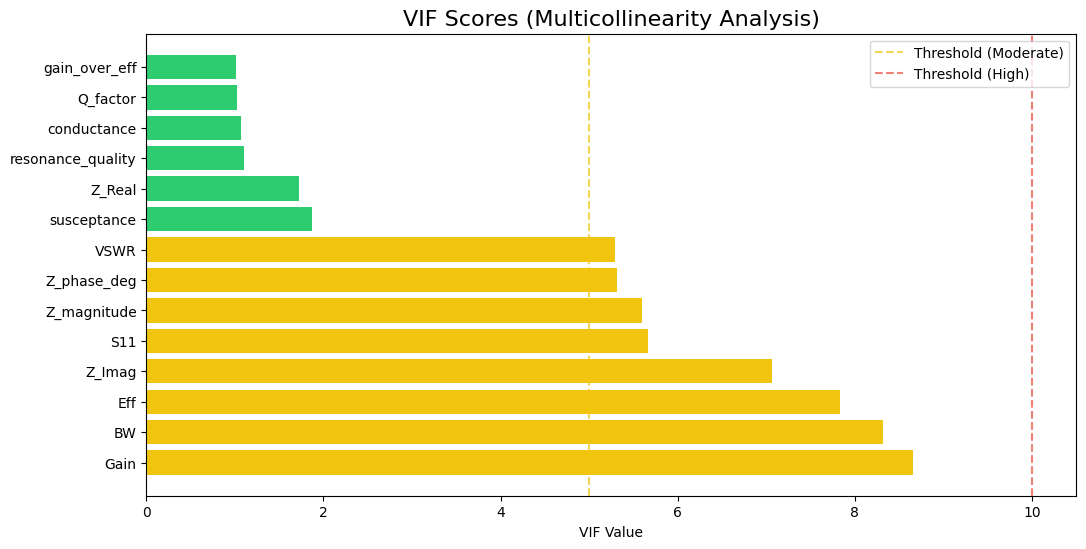

Summary: 14 features analyzed.
High (>10): 0
Moderate (5-10): 8
Normal (<5): 6


In [23]:
df = df_rename_columns(df)
df = perform_feature_engineering(df)
features_advanced = [col for col in df.columns if col not in ["Status", "Fault_Type"]]
vif_results_adv = calculate_vif(df, features_advanced)

# Optimisation

In [24]:
CONFIG = {
    "N_FOLDS": 7,
    "N_TRIALS": 20,
    "RANDOM_STATE": 42,
    "TEST_SIZE": 0.2,
    "MODELS": {
        "Logistic": {
            "class_": LogisticRegression,
            "base_params": {"max_iter": 2000, "solver": "liblinear"},
            "optuna_ranges": {
                "C": {"type": "float", "low": 0.01, "high": 10, "log": True},
                "penalty": {"type": "categorical", "choices": ["l1", "l2"]}
            }
        },
        "RandomForest": {
            "class_": RandomForestClassifier, "base_params": {"n_jobs": -1},
            "optuna_ranges": { "n_estimators": {"type": "int", "low": 20, "high": 150}, "max_depth": {"type": "int", "low": 2, "high": 10} }
        },
        "XGBoost": {
            "class_": XGBClassifier, "base_params": {"n_jobs": -1},
            "optuna_ranges": { "learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True}, "max_depth": {"type": "int", "low": 2, "high": 10} }
        },
        "LightGBM": {
            "class_": LGBMClassifier, "base_params": {"verbose": -1, "n_jobs": -1},
            "optuna_ranges": { "num_leaves": {"type": "int", "low": 20, "high": 150}, "learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True} }
        }
    }
}


In [25]:
print("Setup")
print(f"Pipeline: {len(CONFIG['MODELS'])} models × {CONFIG['N_TRIALS']} trials × {CONFIG['N_FOLDS']} folds")
print(f"Random seed: {CONFIG['RANDOM_STATE']} | Test split: {CONFIG['TEST_SIZE']*100}%")

model_summary = []
for model_name, config in CONFIG["MODELS"].items():
    n_params = len(config["optuna_ranges"])
    model_summary.append({
        "Model": model_name,
        "Params": n_params,
        "Est. trials": f"{CONFIG['N_TRIALS']}×{CONFIG['N_FOLDS']}",
        "Complexity": "High" if n_params >= 5 else "Low"
    })

summary_df = pd.DataFrame(model_summary)
print("\n Model Configuration:")
print(summary_df.to_string(index=False))

total_params = sum(len(config["optuna_ranges"]) for config in CONFIG["MODELS"].values())
total_trials = len(CONFIG["MODELS"]) * CONFIG["N_TRIALS"] * CONFIG["N_FOLDS"]
print(f"Parameters: {total_params}")
print(f"Trials: {total_trials:,}")
print(f"Est. time: ~{total_trials//100:.0f}-{total_trials//50:.0f} min")

Setup
Pipeline: 4 models × 20 trials × 7 folds
Random seed: 42 | Test split: 20.0%

 Model Configuration:
       Model  Params Est. trials Complexity
    Logistic       2        20×7        Low
RandomForest       2        20×7        Low
     XGBoost       2        20×7        Low
    LightGBM       2        20×7        Low
Parameters: 8
Trials: 560
Est. time: ~5-11 min


In [27]:
X = df[features_advanced]
y = df['Fault_Type']

print(f"Features: {len(features_advanced)} | Classes: {len(np.unique(y))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["TEST_SIZE"],
    random_state=CONFIG["RANDOM_STATE"],
    stratify=y
)
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

Features: 14 | Classes: 6
Train shape: (1200, 14)
Test shape:  (300, 14)


In [28]:
def suggest_hyperparams(trial: Trial, model_name: str) -> Dict[str, Any]:

    params = {}
    ranges = CONFIG["MODELS"][model_name]["optuna_ranges"]

    for name, cfg in ranges.items():
        if cfg["type"] == "float":
            params[name] = trial.suggest_float(name, cfg["low"], cfg["high"], log=cfg.get("log", False))
        elif cfg["type"] == "int":
            params[name] = trial.suggest_int(name, cfg["low"], cfg["high"])
        elif cfg["type"] == "categorical":
            params[name] = trial.suggest_categorical(name, cfg["choices"])
    return params


In [29]:
def run_optimization(model_name: str, X: pd.DataFrame, y: pd.Series, skf: StratifiedKFold):

    def objective(trial):
        scores = []
        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_val_s = scaler.transform(X_val)

            params = {**CONFIG["MODELS"][model_name]["base_params"], **suggest_hyperparams(trial, model_name), "random_state": CONFIG["RANDOM_STATE"]}
            model = CONFIG["MODELS"][model_name]["class_"](**params)
            model.fit(X_tr_s, y_tr)
            scores.append(f1_score(y_val, model.predict(X_val_s), average="macro"))
        return np.mean(scores)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=CONFIG["N_TRIALS"], show_progress_bar=True)
    return study.best_params, study.best_value


In [32]:
def optimize_model(model_name: str, X: pd.DataFrame, y: pd.Series, skf: StratifiedKFold) -> Tuple[Dict[str, Any], float]:

    def objective(trial: Trial) -> float:

        cv_scores = []

        for train_idx, val_idx in skf.split(X, y):
            X_tr = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_tr = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            scaler_fold = StandardScaler()
            X_tr_scaled = scaler_fold.fit_transform(X_tr)
            X_val_scaled = scaler_fold.transform(X_val)

            params = suggest_hyperparams(trial, model_name)
            model_cls = CONFIG["MODELS"][model_name]["class_"]
            model_params = {
                **CONFIG["MODELS"][model_name]["base_params"],
                **params,
                "random_state": CONFIG["RANDOM_STATE"]
            }

            model = model_cls(**model_params)
            model.fit(X_tr_scaled, y_tr)
            y_pred = model.predict(X_val_scaled)
            cv_scores.append(f1_score(y_val, y_pred, average="macro"))

        return np.mean(cv_scores)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=CONFIG["N_TRIALS"], show_progress_bar=True)
    return study.best_params, study.best_value

In [34]:
skf = StratifiedKFold(n_splits=CONFIG["N_FOLDS"], shuffle=True, random_state=CONFIG["RANDOM_STATE"])

print("Optimisation")
print(f"Pipeline: {len(CONFIG['MODELS'])} models | {CONFIG['N_TRIALS']} trials × {CONFIG['N_FOLDS']} folds")
print(f"CV metric: F1_macro")

results = []

for i, model_name in enumerate(CONFIG["MODELS"], 1):
    print(f"\n[{i}/{len(CONFIG['MODELS'])}] {model_name:^12} {'':>20}", end="")
    start_time = time.time()

    best_params, best_cv = optimize_model(model_name, X, y, skf)
    optuna_time = time.time() - start_time

    scaler_final = StandardScaler()
    X_train_scaled = scaler_final.fit_transform(X_train)
    X_test_scaled = scaler_final.transform(X_test)

    model_cls = CONFIG["MODELS"][model_name]["class_"]
    model_params = {
        **CONFIG["MODELS"][model_name]["base_params"],
        **best_params,
        "random_state": CONFIG["RANDOM_STATE"]
    }
    model = model_cls(**model_params)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    result = {
        "Model_name": model_name,
        "Model_params": model,
        "Accuracy": accuracy_score(y_test, y_pred),
        "P_weighted": precision_score(y_test, y_pred, average="weighted"),
        "R_weighted": recall_score(y_test, y_pred, average="weighted"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "P_macro": precision_score(y_test, y_pred, average="macro"),
        "R_macro": recall_score(y_test, y_pred, average="macro"),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "CV_F1_macro": best_cv,
        "Optuna_Time": f"{optuna_time:.1f}s",
        "N_Trials": CONFIG["N_TRIALS"],
        "N_Folds": CONFIG["N_FOLDS"]
    }
    results.append(result)
    print(f"   {model_name:12} | Test F1_macro: {result['F1_macro']:.4f} | CV: {best_cv:.4f} | {optuna_time:.1f}s")
    print(f"   Gap(CV→Test): {(best_cv-result['F1_macro']):+.4f} | Accuracy: {result['Accuracy']:.3f}")

Optimisation
Pipeline: 4 models | 20 trials × 7 folds
CV metric: F1_macro

[1/4]   Logistic                       

  0%|          | 0/20 [00:00<?, ?it/s]

   Logistic     | Test F1_macro: 0.9933 | CV: 0.9933 | 18.1s
   Gap(CV→Test): +0.0000 | Accuracy: 0.993

[2/4] RandomForest                     

  0%|          | 0/20 [00:00<?, ?it/s]

   RandomForest | Test F1_macro: 1.0000 | CV: 1.0000 | 47.3s
   Gap(CV→Test): +0.0000 | Accuracy: 1.000

[3/4]   XGBoost                        

  0%|          | 0/20 [00:00<?, ?it/s]

   XGBoost      | Test F1_macro: 1.0000 | CV: 1.0000 | 53.3s
   Gap(CV→Test): +0.0000 | Accuracy: 1.000

[4/4]   LightGBM                       

  0%|          | 0/20 [00:00<?, ?it/s]

   LightGBM     | Test F1_macro: 1.0000 | CV: 0.9993 | 147.1s
   Gap(CV→Test): -0.0007 | Accuracy: 1.000


# Results

In [35]:
results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False)

styled_df = results_df.style\
    .background_gradient(subset=["Accuracy", "F1_macro", "CV_F1_macro"], cmap="RdYlGn")\
    .format({"F1_macro": "{:.4f}", "CV_F1_macro": "{:.4f}", "Accuracy": "{:.3f}"})
display(styled_df)

,Model_name,Model_params,Accuracy,P_weighted,R_weighted,F1_weighted,P_macro,R_macro,F1_macro,CV_F1_macro,Optuna_Time,N_Trials,N_Folds
1,RandomForest,"RandomForestClassifier(max_depth=9, n_estimators=49, n_jobs=-1, random_state=42)",1.000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.0000,47.3s,20,7
2,XGBoost,"XGBClassifier(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=False, eval_metric=None, feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=0.07394506445108003, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=7, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=-1, num_parallel_tree=None, ...)",1.000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.0000,53.3s,20,7
3,LightGBM,"LGBMClassifier(learning_rate=0.14336514484590335, n_jobs=-1, num_leaves=122, random_state=42, verbose=-1)",1.000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,0.9993,147.1s,20,7
0,Logistic,"LogisticRegression(C=9.262640293257839, max_iter=2000, penalty='l1', random_state=42, solver='liblinear')",0.993,0.993590,0.993333,0.993331,0.993590,0.993333,0.9933,0.9933,18.1s,20,7


In [36]:
def plot_confusion_matrix(y_true, y_pred, model_name, score):

    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    labels = sorted(y_true.unique())

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"{model_name} Confusion Matrix\n(F1 Macro: {score:.4f})", fontsize=16)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [37]:
def plot_feature_importance(model, features, top_n=10):

    if not hasattr(model, "feature_importances_"): return

    imp_df = pd.DataFrame({"Feature": features, "Importance": model.feature_importances_})
    imp_df = imp_df.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=imp_df, x="Importance", y="Feature", palette="viridis")
    plt.title(f"Top {top_n} Feature Importances", fontsize=16)
    plt.show()


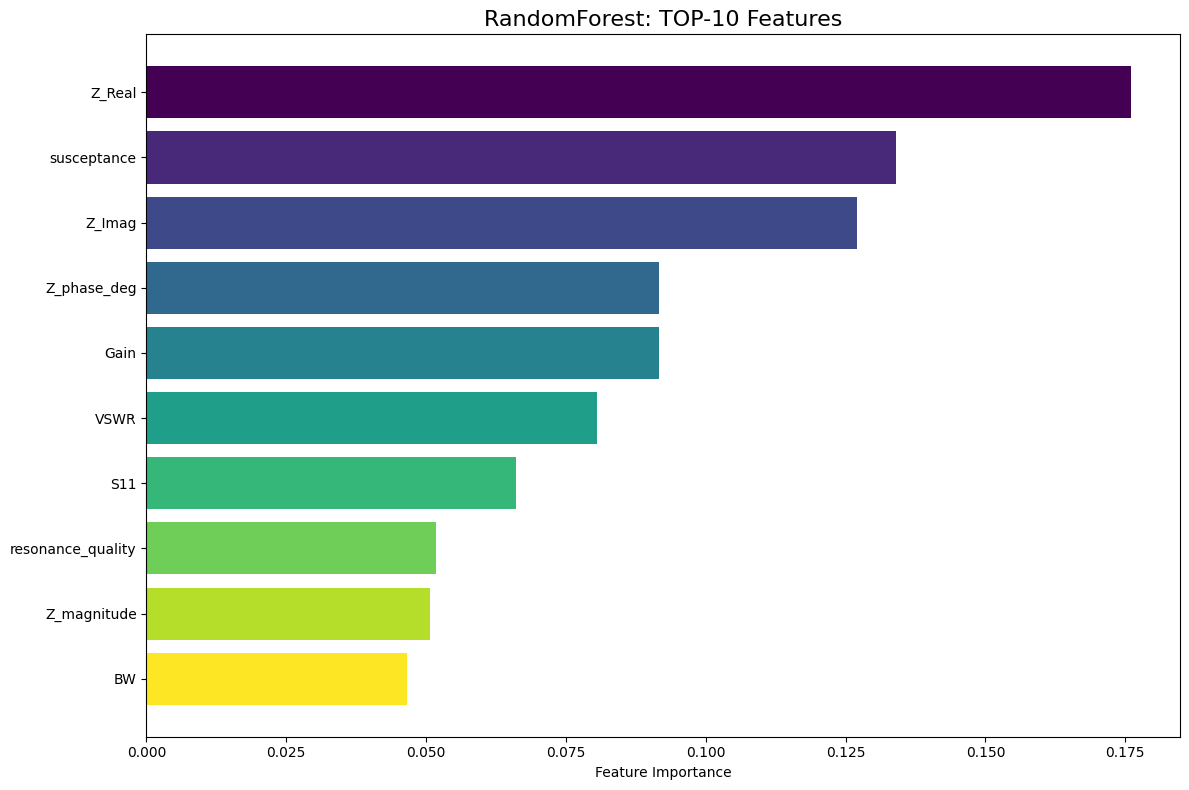


 Top-10 Features:


,Feature,Importance
5,Z_Real,0.1760
11,susceptance,0.1341
6,Z_Imag,0.1270
8,Z_phase_deg,0.0916
2,Gain,0.0916
1,VSWR,0.0806
0,S11,0.0661
13,resonance_quality,0.0518
7,Z_magnitude,0.0508
4,BW,0.0467


In [40]:
features_count = 10

# Extract the top performing model from results
best_result = results_df.iloc[0]
best_model = best_result['Model_params']
best_name = best_result['Model_name']

if hasattr(best_model, 'feature_importances_'):
    # Use features_advanced (14 cols) because the models were trained on X_train (14 cols)
    importance_df = pd.DataFrame({
        'Feature': features_advanced,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(features_count)

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(importance_df)), importance_df['Importance'],
             color=plt.cm.viridis(np.linspace(0, 1, len(importance_df))))
    plt.yticks(range(len(importance_df)), importance_df['Feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'{best_name}: TOP-{features_count} Features', fontsize=16)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(f"\n Top-{features_count} Features:")
    display(importance_df.head(features_count).style.format({'Importance': '{:.4f}'}))
else:
    print(f"No feature importances for {best_name}")